In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers 
import numpy as np
import pandas as pd
import random, os
import cv2
import shutil
import keras
import matplotlib.pyplot as plt
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import categorical_accuracy
from sklearn.model_selection import train_test_split


In [3]:
df = pd.read_csv('train.csv')

diagnosis_binary = {
    0:'No_DR',
    1:'DR',
    2:'DR',
    3:'DR',
    4:'DR'
}

diagnosis_classes = {
    0:'No_DR',
    1:'Mild',
    2:'Moderate',
    3:'Severe',
    4:'Proliferate_DR'
}

df['binary'] = df['diagnosis'].map(diagnosis_binary.get)
df['type'] = df['diagnosis'].map(diagnosis_classes.get)

In [4]:
df.head()


,id_code,diagnosis,binary,type
0,000c1434d8d7,2,DR,Moderate
1,001639a390f0,4,DR,Proliferate_DR
2,0024cdab0c1e,1,DR,Mild
3,002c21358ce6,0,No_DR,No_DR
4,005b95c28852,0,No_DR,No_DR


<Axes: ylabel='type'>

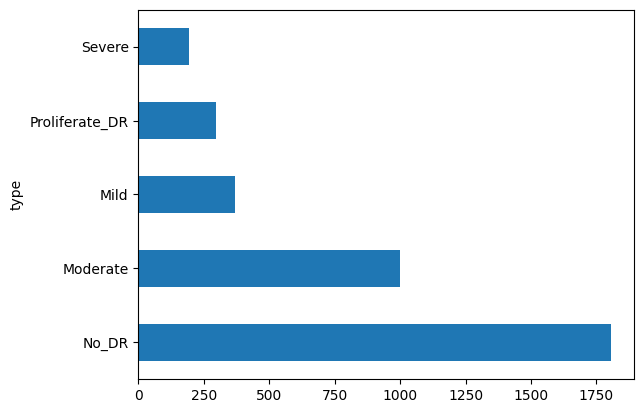

In [40]:
df['type'].value_counts().plot(kind='barh')


<Axes: ylabel='binary'>

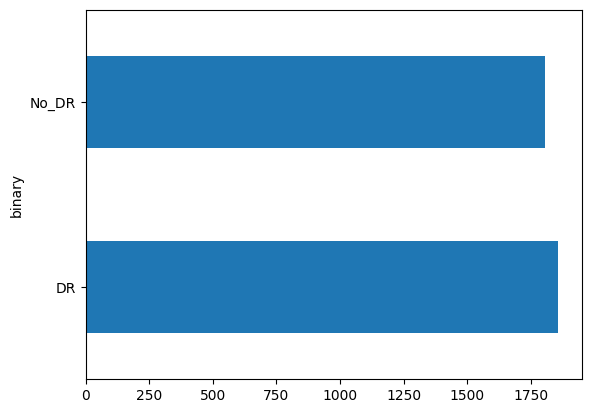

In [6]:
df['binary'].value_counts().plot(kind='barh')


In [7]:
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from sklearn.preprocessing import LabelBinarizer
from imutils import paths
from sklearn.utils import shuffle

In [11]:
data=[]
labels=[]
width,height=224,224

imagePaths = list(paths.list_images(r"C:\Users\harik\Documents\COLLEGE\SEM6\AI&EdgeComputing\colored_images"))

for imagePath in imagePaths:
    label = imagePath.split(os.path.sep)[-2]
    image=load_img(imagePath, target_size = (width,height))
    image = img_to_array(image)
    data.append(image)
    labels.append(label)

data=np.array(data,dtype='float32')
labels = np.array(labels)

lb=LabelBinarizer()
labels = lb.fit_transform(labels)

data,labels = shuffle(data,labels)

print(data.shape)
print(labels.shape)

(3662, 224, 224, 3)
(3662, 5)


In [12]:
x_train, x_test, y_train, y_test = train_test_split(data,labels,test_size=.2)

print('Train images:',x_train.shape)
print('Test images',x_test.shape)
print('Train label:',y_train.shape)
print('Test label:',y_test.shape)

Train images: (2929, 224, 224, 3)
Test images (733, 224, 224, 3)
Train label: (2929, 5)
Test label: (733, 5)


In [13]:
x_train, x_val, y_train, y_val = train_test_split(x_train,y_train,test_size=.2)

print('Train images:',x_train.shape)
print('Validation images',x_val.shape)
print('Train label:',y_train.shape)
print('Validation label:',y_val.shape)

Train images: (2343, 224, 224, 3)
Validation images (586, 224, 224, 3)
Train label: (2343, 5)
Validation label: (586, 5)


In [14]:
from keras.models import Model
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Activation, BatchNormalization, Dropout
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.applications.vgg16 import VGG16
from keras import layers

In [15]:
Vgg16 = VGG16(include_top = False, input_shape=(224,224,3))
Vgg16.trainable  =False


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 50s 1us/step


In [18]:
model = Sequential()
model.add(Vgg16)
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(32, activation='relu'))
model.add(Dense(5,activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])


In [19]:
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,322,629 (62.27 MB)

 Trainable params: 1,607,941 (6.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Num GPUs Available: 0


In [22]:
callbacks = [EarlyStopping(monitor = 'val_binary_accuracy',patience=10,restore_best_weights=True)]
history = model.fit(x_train,y_train,epochs=10,batch_size=64,validation_data=(x_val,y_val),verbose=1,callbacks=callbacks)


Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 216s 6s/step - binary_accuracy: 0.8922 - loss: 0.2877 - val_binary_accuracy: 0.9044 - val_loss: 0.2545
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 214s 6s/step - binary_accuracy: 0.9059 - loss: 0.2431 - val_binary_accuracy: 0.9031 - val_loss: 0.2542
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 215s 6s/step - binary_accuracy: 0.9036 - loss: 0.2337 - val_binary_accuracy: 0.9089 - val_loss: 0.2455
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 213s 6s/step - binary_accuracy: 0.9123 - loss: 0.2237 - val_binary_accuracy: 0.9147 - val_loss: 0.2353
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 213s 6s/step - binary_accuracy: 0.9170 - loss: 0.2191 - val_binary_accuracy: 0.9164 - val_loss: 0.2284
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 213s 6s/step - binary_accuracy: 0.9162 - loss: 0.2101 - val_binary_accuracy: 0.9164 - val_loss: 0.2399
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 214s 6s/step - binary_accuracy: 0.9164 - loss: 0.1999 - val_binary_accuracy: 0.9133 - val_loss: 0.2366
Epoch 8/10
37

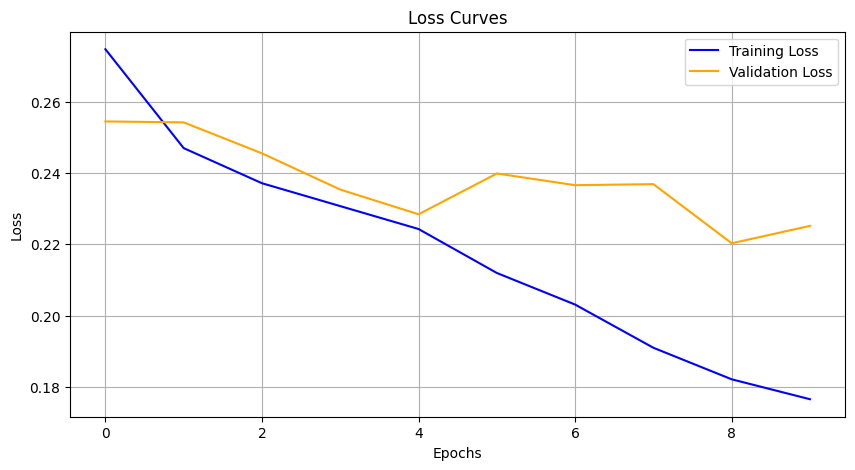

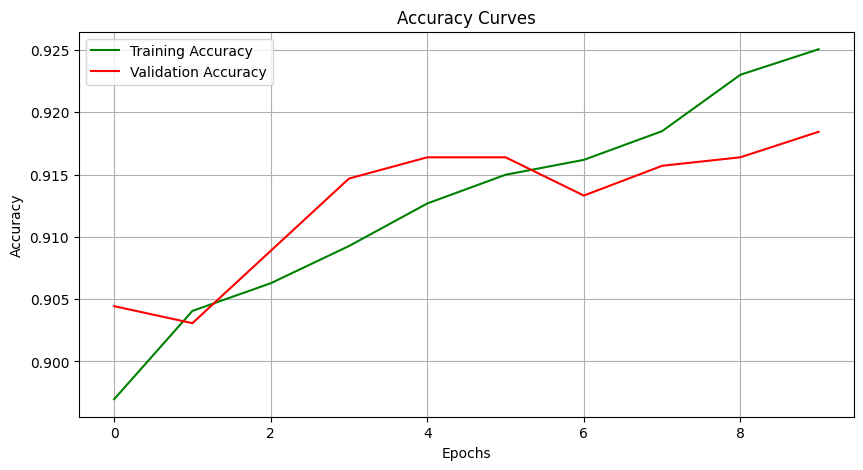

In [ ]:
import matplotlib.pyplot as plt

def plot_curves(history):
    # Extract loss and accuracy from history object
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    accuracy = history.history['binary_accuracy']
    val_accuracy = history.history['val_binary_accuracy']

    epochs = range(len(loss))

    # Plot Loss Curves
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, loss, label='Training Loss', color='blue')
    plt.plot(epochs, val_loss, label='Validation Loss', color='orange')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Accuracy Curves
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, accuracy, label='Training Accuracy', color='green')
    plt.plot(epochs, val_accuracy, label='Validation Accuracy', color='red')
    plt.title('Accuracy Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_curves(history)


23/23 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step
[0 1 0 0 0]
Prediction: Moderate


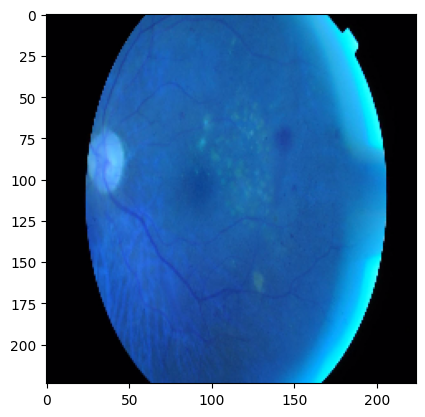

In [30]:
index = 5
predictions = ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']

# Ensure prediction array
pred = model.predict(x_test)
pred = np.argmax(pred, axis=1)

img = x_test[index]
RGBImg = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
RGBImg = cv2.resize(RGBImg, (224, 224))
RGBImg = np.clip(RGBImg, 0, 255).astype(np.uint8)

plt.imshow(RGBImg)
print(y_test[index])
print(f"Prediction: {predictions[pred[index]]}")


In [31]:
import cv2

def predict_new(path):
    img= cv2.imread(path)
    RGBImg = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    RGBImg= cv2.resize(RGBImg, (224,224))
    plt.imshow(RGBImg)
    image = np.array (RGBImg) / 255.0
    predict=model.predict(np.array([image]))
    pred=np.argmax(predict, axis=1)
    print(f"Predicted: {predictions [pred[0]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
Predicted: Moderate


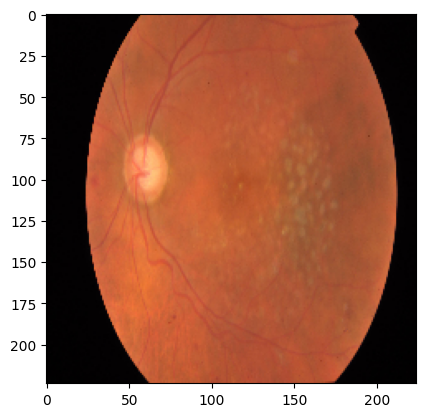

In [36]:
predict_new(r'C:\Users\harik\Documents\COLLEGE\SEM6\AI&EdgeComputing\colored_images\Moderate\1c5ad36fb799.png')